<a href="https://colab.research.google.com/github/2422161csedscec-blip/Project-1/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Customer Data Preprocessing
Pipeline

Objective:  
To prepare raw customer data for machine learning and data analysis by performing essential preprocessing steps such as handling missing values, removing duplicate records, feature scaling, feature encoding, and cleaning inconsistent data. The goal is to transform the dataset into a structured, accurate, and analysis-ready format that improves model performance and ensures reliable results.

In [76]:
import pandas as pd
df=pd.read_csv('/content/consumers-price-index-march-2026-quarter-index-numbers.csv')
df.head()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import os

#1. To Load Data

df=pd.read_csv('/content/consumers-price-index-march-2026-quarter-index-numbers.csv')
df.head()
# df.tail()

,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2
0,CPIQ.SE901,1914.06,13.167858,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
1,CPIQ.SE901,1914.09,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
2,CPIQ.SE901,1914.12,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
3,CPIQ.SE901,1915.03,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
4,CPIQ.SE901,1915.06,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN


In [77]:
#  2. Handle Missing values
import pandas as pd
import matplotlib.pyplot as plt

df.isnull().sum()

,0
Series_reference,0
Period,0
Data_value,29
STATUS,0
UNITS,0
Subject,0
Group,0
Series_title_1,0
Series_title_2,22538


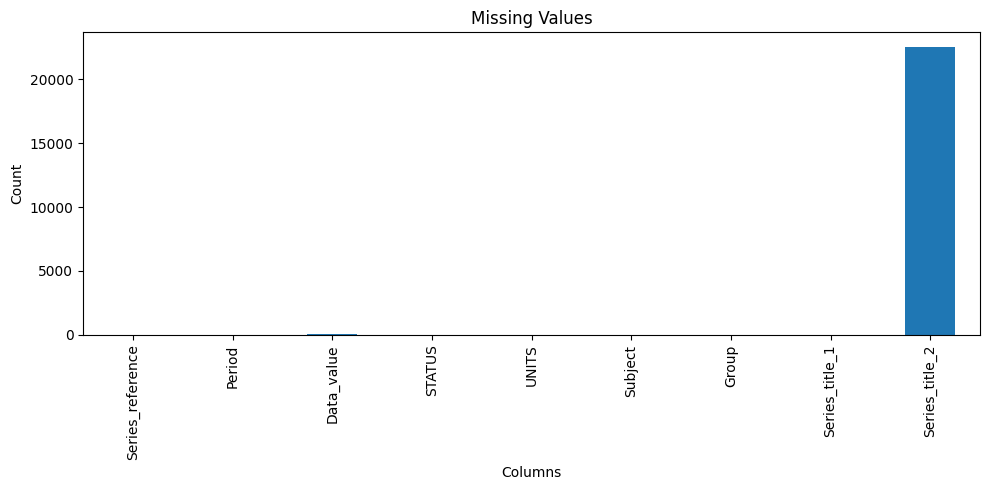

In [78]:

# 2. Handle Missing values

missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [79]:
# 3. Feature Engineering

# Create a new feature from Data_value

df["Value_Category"] = pd.cut(
    df["Data_value"],
    bins=3,
    labels=["Low", "Medium", "High"]
)
df.describe()

,Period,Data_value,Series_title_2
count,22538.000000,22509.000000,0.0
mean,2006.275292,962.024091,NaN
std,15.150732,1281.514800,NaN
min,1914.060000,0.000000,NaN
25%,2000.030000,673.306773,NaN
50%,2008.120000,951.816746,NaN
75%,2017.090000,1055.000000,NaN
max,2026.030000,27976.190476,NaN


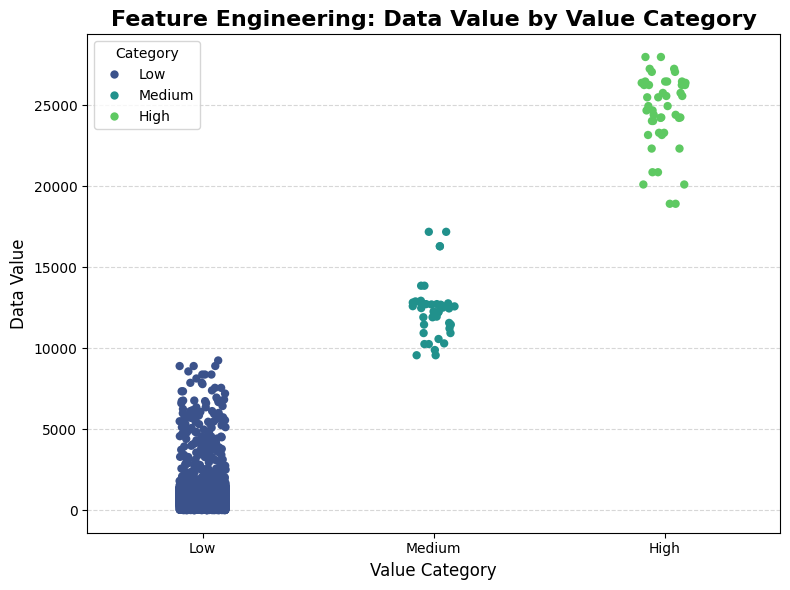

In [80]:
# 3. Feature Engineering

# Create a new feature from Data_value

df["Value_Category"] = pd.cut(
    df["Data_value"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Strip Plot

plt.figure(figsize=(8,6))

sns.stripplot(
    data=df,
    x="Value_Category",
    y="Data_value",
    hue="Value_Category",
    palette="viridis",
    jitter=True,
    size=6
)

plt.title("Feature Engineering: Data Value by Value Category",
          fontsize=16, fontweight="bold")
plt.xlabel("Value Category", fontsize=12)
plt.ylabel("Data Value", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Category")

plt.tight_layout()
plt.show()

In [81]:
# 4. Feature scaling
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load CSV file
df = pd.read_csv("consumers-price-index-march-2026-quarter-index-numbers.csv")

# Apply MinMaxScaler on Data_value column
scaler = MinMaxScaler()

df["MinMax_Scaled"] = scaler.fit_transform(df[["Data_value"]])

print(df[["Data_value", "MinMax_Scaled"]])

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load CSV file
df = pd.read_csv("consumers-price-index-march-2026-quarter-index-numbers.csv")

# Apply StandardScaler on Data_value column
scaler = StandardScaler()

df["Standard_Scaled"] = scaler.fit_transform(df[["Data_value"]])

print(df[["Data_value", "Standard_Scaled"]])

        Data_value  MinMax_Scaled
0        13.167858       0.000471
1         0.000000       0.000000
2         0.000000       0.000000
3         0.000000       0.000000
4         0.000000       0.000000
...            ...            ...
22533  1299.000000       0.046432
22534  1306.000000       0.046683
22535  1319.000000       0.047147
22536  1327.000000       0.047433
22537  1339.000000       0.047862

[22538 rows x 2 columns]
        Data_value  Standard_Scaled
0        13.167858        -0.740434
1         0.000000        -0.750710
2         0.000000        -0.750710
3         0.000000        -0.750710
4         0.000000        -0.750710
...            ...              ...
22533  1299.000000         0.262957
22534  1306.000000         0.268419
22535  1319.000000         0.278564
22536  1327.000000         0.284807
22537  1339.000000         0.294171

[22538 rows x 2 columns]


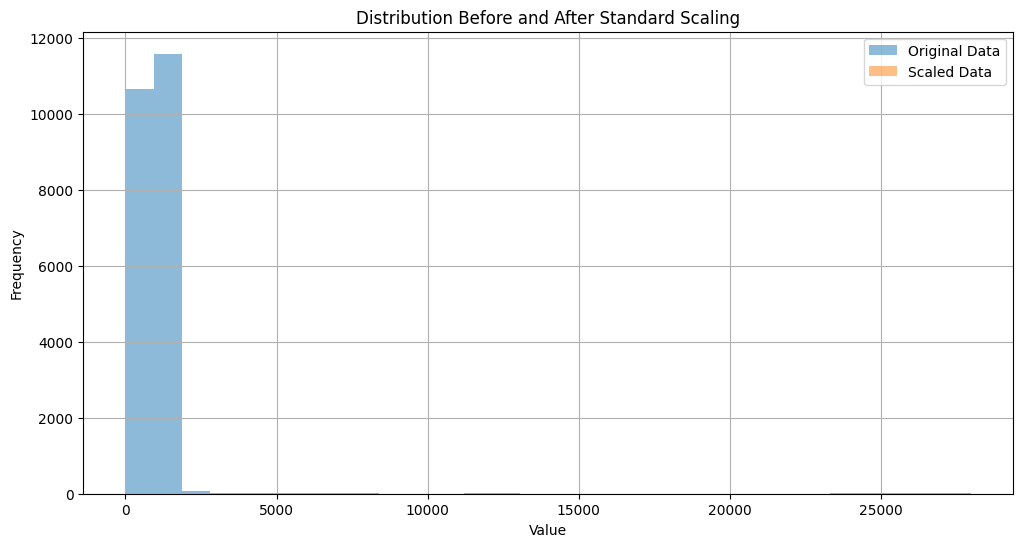

In [82]:
# 4. Feature scaling
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Data_value']])

# Plot histogram
plt.figure(figsize=(12,6))

plt.hist(df['Data_value'], bins=30, alpha=0.5, label='Original Data')
plt.hist(scaled_data, bins=30, alpha=0.5, label='Scaled Data')

plt.title("Distribution Before and After Standard Scaling")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [83]:
# 5. Feature Encoding:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("consumers-price-index-march-2026-quarter-index-numbers.csv")

# Label Encoding
le = LabelEncoder()
label_df = df[["STATUS"]].copy()
label_df["STATUS_Encoded"] = le.fit_transform(label_df["STATUS"])

print("Label Encoding Output:")
print(label_df.head())

# # One Hot Encoding
df = pd.get_dummies(df, columns=["Group"])

print("\nOne-Hot Encoding Output:")
print(df.head())

Label Encoding Output:
  STATUS  STATUS_Encoded
0  FINAL               0
1  FINAL               0
2  FINAL               0
3  FINAL               0
4  FINAL               0

One-Hot Encoding Output:
  Series_reference   Period  Data_value STATUS  UNITS Subject Series_title_1  \
0       CPIQ.SE901  1914.06   13.167858  FINAL  Index     CPI           Food   
1       CPIQ.SE901  1914.09    0.000000  FINAL  Index     CPI           Food   
2       CPIQ.SE901  1914.12    0.000000  FINAL  Index     CPI           Food   
3       CPIQ.SE901  1915.03    0.000000  FINAL  Index     CPI           Food   
4       CPIQ.SE901  1915.06    0.000000  FINAL  Index     CPI           Food   

   Series_title_2  Group_CPI All Groups for New Zealand  \
0             NaN                                 False   
1             NaN                                 False   
2             NaN                                 False   
3             NaN                                 False   
4             NaN        

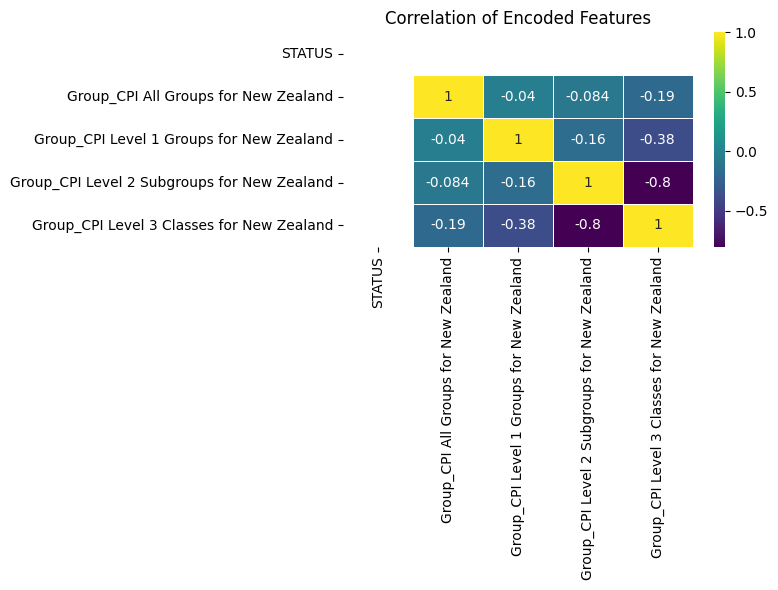

In [84]:
# 5. Feature Encoding:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Label Encoding
le = LabelEncoder()
df["STATUS"] = le.fit_transform(df["STATUS"])

# One-Hot Encoding (already performed by cell beFcJXJVnyF4, so this line is removed)

# Graph: Correlation of Encoded Features
encoded_cols = ["STATUS"] + [col for col in df.columns if col.startswith("Group_")]

corr = df[encoded_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Correlation of Encoded Features")

plt.tight_layout()
plt.show()

In [85]:

# 6.Output of cleaned data

# Remove missing values from 'Data_value'
df = df.dropna(subset=['Data_value'])

# Remove duplicate rows
df = df.drop_duplicates()

# Scale the 'Data_value' column
scaler = MinMaxScaler()

df["Scaled_Data_value"] = scaler.fit_transform(df[["Data_value"]])

# Output of cleaned data
print(df.head(5))

  Series_reference   Period  Data_value  STATUS  UNITS Subject Series_title_1  \
0       CPIQ.SE901  1914.06   13.167858       0  Index     CPI           Food   
1       CPIQ.SE901  1914.09    0.000000       0  Index     CPI           Food   
2       CPIQ.SE901  1914.12    0.000000       0  Index     CPI           Food   
3       CPIQ.SE901  1915.03    0.000000       0  Index     CPI           Food   
4       CPIQ.SE901  1915.06    0.000000       0  Index     CPI           Food   

   Series_title_2  Group_CPI All Groups for New Zealand  \
0             NaN                                 False   
1             NaN                                 False   
2             NaN                                 False   
3             NaN                                 False   
4             NaN                                 False   

   Group_CPI Level 1 Groups for New Zealand  \
0                                      True   
1                                      True   
2                

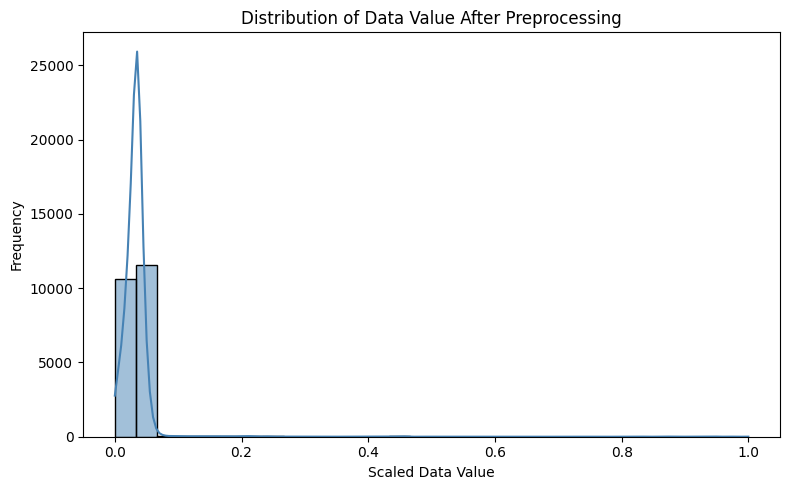

In [86]:
# 6.Output of cleaned data

# Scale the 'Data_value' column to create scaled_df
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Data_value']])
scaled_df = pd.DataFrame(scaled_data, columns=['Data_value'])

plt.figure(figsize=(8,5))

sns.histplot(
    data=scaled_df,
    x="Data_value",
    kde=True,
    bins=30,
    color="steelblue"
)

plt.title("Distribution of Data Value After Preprocessing")
plt.xlabel("Scaled Data Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Conclusion:

The customer data preprocessing pipeline successfully transformed raw data into a clean and structured format suitable for analysis and machine learning. By handling missing values, removing duplicate records, applying feature scaling techniques such as MinMaxScaler and StandardScaler, and performing feature encoding using Label Encoding and One-Hot Encoding, the dataset became more consistent and reliable. These preprocessing steps improve data quality, enhance model accuracy, and ensure better performance in future predictive analysis and decision-making tasks.